# Dataset IRIS

Наша мета полягає у побудові моделі машинного навчанняб яка зможе навчитися на основі характеристик ірисів, вже класифікованих за сортами, а потім передбачить сорт для нової квітки ірису.

Оскільки вже є приклади по яких ми знаємо правильні сорти ірисів, то це задача навчання з вчителем. Потрібно спрогнозувати один з сортів - це задача класифікації.

Завантаження даних

In [1]:
from sklearn.datasets import load_iris
iris_dataset = load_iris()

Об'єкт iris, який повертає load_iris є об'єктом Bunch, схожим на словник, має ключі та значення.

In [2]:
print('Keys iris_dataset: \n{}'.format(iris_dataset.keys()))

Keys iris_dataset: 
dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


Значення ключа DESCR - короткий опис набору даних

In [3]:
print(iris_dataset['DESCR'][:] + '\n...')

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

    :Number of Instances: 150 (50 in each of three classes)
    :Number of Attributes: 4 numeric, predictive attributes and the class
    :Attribute Information:
        - sepal length in cm
        - sepal width in cm
        - petal length in cm
        - petal width in cm
        - class:
                - Iris-Setosa
                - Iris-Versicolour
                - Iris-Virginica
                
    :Summary Statistics:

    ============== ==== ==== ======= ===== ====================
                    Min  Max   Mean    SD   Class Correlation
    ============== ==== ==== ======= ===== ====================
    sepal length:   4.3  7.9   5.84   0.83    0.7826
    sepal width:    2.0  4.4   3.05   0.43   -0.4194
    petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
    petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
    ============== ==== ==== ======= ===== ===========

Значення ключа target_names - масив рядків з назвами сортів, які потрібно визначити

In [4]:
print('Answers names: {}'.format(iris_dataset['target_names']))

Answers names: ['setosa' 'versicolor' 'virginica']


Значення ключа Features names - список рядків з описом кожного признаку



In [5]:
print('Features names: \n{}'.format(iris_dataset['feature_names']))

Features names: 
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [6]:
print('Type of data arrays: {}'.format(type(iris_dataset['data'])))

Type of data arrays: <class 'numpy.ndarray'>


In [7]:
print('Shape of data arrays: {}'.format(iris_dataset['data'].shape))

Shape of data arrays: (150, 4)


In [8]:
print('First rows of dataset: \n{}'.format(iris_dataset['data'][:5]))

First rows of dataset: 
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


In [9]:
print('Shape of target array: {}'.format(iris_dataset['target'].shape))

Shape of target array: (150,)


In [10]:
print('Answers: {}'.format(iris_dataset['target']))

Answers: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [41]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(iris_dataset['data'], iris_dataset['target'],test_size = 0.33,  random_state = 42)

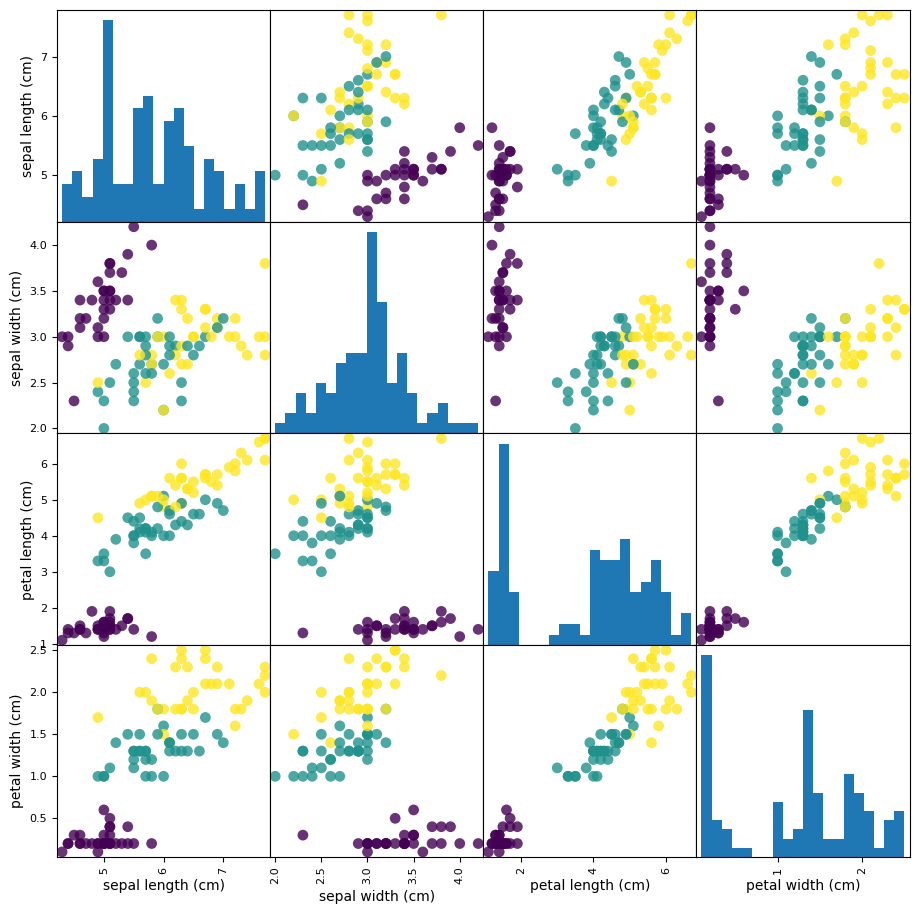

In [42]:
import pandas as pd
from pandas.plotting import scatter_matrix
iris_dataframe = pd.DataFrame(X_train, columns = iris_dataset.feature_names)
grr = scatter_matrix(iris_dataframe, c = y_train, figsize = (11, 11),marker = 'o',
                     hist_kwds = {'bins': 20}, s = 60, alpha = 0.8)


In [43]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=2)

In [44]:
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=2)

In [45]:
import numpy as np
X_new = np.array([[5, 2.9, 1, 0.2]])

In [46]:
prediction = knn.predict(X_new)
print('Prediction: {}'.format(prediction))
print('Name: {}'.format(iris_dataset['target_names'][prediction]))

Prediction: [0]
Name: ['setosa']


In [47]:
y_pred = knn.predict(X_test)
print('Prediction for test_set: \n {}'.format(y_pred))

Prediction for test_set: 
 [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0 0 0 2 1 1 0 0 1 1 2 1 2]


In [48]:
y_test

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 2, 1, 1, 0,
       0, 1, 2, 2, 1, 2])

In [49]:
print('Part of correct answeeres: {:.2f}'.format(np.mean(y_pred == y_test)))

Part of correct answeeres: 0.98


In [50]:
print('Part of correct answeeres: {:.2f}'.format(knn.score(X_test, y_test)))

Part of correct answeeres: 0.98
